This notebook does some comparison between extracted and raw flair data to verify if the extracted data is correct. First we check for some temporary basals (sets to zero temporarily) and auto mode. Then, we compare extracted vs. reported TDD.

In [1]:
#imports
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '..','..'))
from datetime import datetime, timedelta
import pandas as pd
from matplotlib import pyplot as plt

%matplotlib inline

from studies import DCLP3,DCLP5,ReplaceBG,Flair,Loop,PEDAP,IOBP2, T1DEXI, T1DEXIP
from src import drawing, cdf, tdd, logger, pandas_helper
from studies.studydataset import StudyDataset
import logging
logger = logger.Logger.get_logger("",logging.WARNING)

In [2]:
data_path = os.path.join(os.getcwd(),'..','..','data','raw')
flair = Flair(os.path.join(data_path, 'FLAIRPublicDataSet'))

## temp events
Get zero temp events and plot extracted data around the zero temp event and draw the raw data. 
Do they match?

In [10]:
basals = flair.extract_basal_event_history()

In [11]:
#get sample where we know there is a temporary basal
zero_temps = flair.df_pump[flair.df_pump.TempBasalAmt==0]

,PtID,DataDtTm,BasalRt,TempBasalAmt,TempBasalType,TempBasalDur,BolusDeliv,ExtendBolusDuration,Suspend,TDD,AutoModeStatus,DateTime
4155913,63,9/21/2018 7:37:44 PM,NaN,0.0,Percent,00:30:00,NaN,NaN,NaN,NaN,NaN,2018-09-21 19:37:44


,patient_id,datetime,basal_rate
963190,63,2018-09-21 09:35:00,1.10
963188,63,2018-09-21 11:01:00,0.00
963187,63,2018-09-21 11:31:00,1.10
963135,63,2018-09-21 12:43:00,0.00
963131,63,2018-09-21 13:13:00,1.10
963125,63,2018-09-21 14:00:00,1.00
963058,63,2018-09-21 17:45:00,0.00
963057,63,2018-09-21 18:15:00,1.00
963055,63,2018-09-21 18:31:00,0.00
963054,63,2018-09-21 19:01:00,1.00


,PtID,DataDtTm,BasalRt,TempBasalAmt,TempBasalType,TempBasalDur,BolusDeliv,TDD,DateTime
963059,63,9/21/2018 5:44:07 PM,NaN,0.0,Percent,0:30:00,NaN,NaN,2018-09-21 17:44:07
963058,63,9/21/2018 5:45:00 PM,1.00,NaN,NaN,NaN,NaN,NaN,2018-09-21 17:45:00
963057,63,9/21/2018 6:15:00 PM,1.00,NaN,NaN,NaN,NaN,NaN,2018-09-21 18:15:00
4155914,63,9/21/2018 6:30:50 PM,NaN,0.0,Percent,00:30:00,NaN,NaN,2018-09-21 18:30:50
963056,63,9/21/2018 6:30:50 PM,NaN,0.0,Percent,0:30:00,NaN,NaN,2018-09-21 18:30:50
963055,63,9/21/2018 6:31:00 PM,1.00,NaN,NaN,NaN,NaN,NaN,2018-09-21 18:31:00
963054,63,9/21/2018 7:01:00 PM,1.00,NaN,NaN,NaN,NaN,NaN,2018-09-21 19:01:00
963053,63,9/21/2018 7:37:44 PM,NaN,0.0,Percent,0:30:00,NaN,NaN,2018-09-21 19:37:44
4155913,63,9/21/2018 7:37:44 PM,NaN,0.0,Percent,00:30:00,NaN,NaN,2018-09-21 19:37:44
963052,63,9/21/2018 7:38:00 PM,1.00,NaN,NaN,NaN,NaN,NaN,2018-09-21 19:38:00


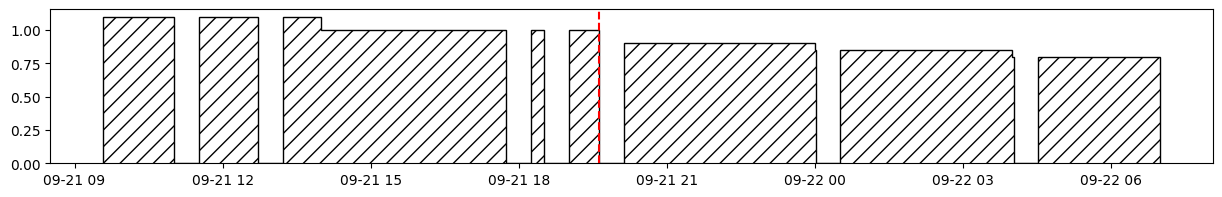

In [12]:
#draw sample
sample = zero_temps.sample()
datetime = pd.to_datetime(sample.DateTime.values[0])
patient_id = str(sample.PtID.values[0])
display(sample)

#get surrounding rows of extracted data
temp = basals[(basals.patient_id==patient_id) & (basals.datetime< (datetime+timedelta(hours=12))) & (basals.datetime > (datetime-timedelta(hours=12)))]
display(temp)

#display surrounding raw data
context = pandas_helper.extract_surrounding_rows(flair.df_pump.loc[flair.df_pump.PtID==sample.PtID.values[0]], sample.index[0],8,sort_by=['PtID','DateTime'])
display(context.dropna(axis=1, how='all'))

#plot
plt.figure(figsize=(15,2)) ; ax=plt.gca()
drawing.drawAbsoluteBasalRates(ax,temp.datetime.values, temp.basal_rate.values)
#mark the sample event
plt.axvline(datetime, color='r', linestyle='--')


As we can see, the extracted data shows temporary 0 rates when the temporary event in the raw data is present

## AutoModeStatus
Here, we check if a auto mode status on successfully causes a zero basal rate.

In [13]:
#get sample where we know there is a temporary basal
cl_mdes = flair.df_pump[flair.df_pump.AutoModeStatus==True]

,PtID,DataDtTm,BasalRt,TempBasalAmt,TempBasalType,TempBasalDur,BolusDeliv,ExtendBolusDuration,Suspend,TDD,AutoModeStatus,DateTime
2796842,23,12/2/2018 2:16:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,2018-12-02 02:16:00


,patient_id,datetime,basal_rate
2797754,23,2018-12-01 14:22:38,0.0
2797124,23,2018-12-02 02:13:00,1.1
2796842,23,2018-12-02 02:16:00,0.0


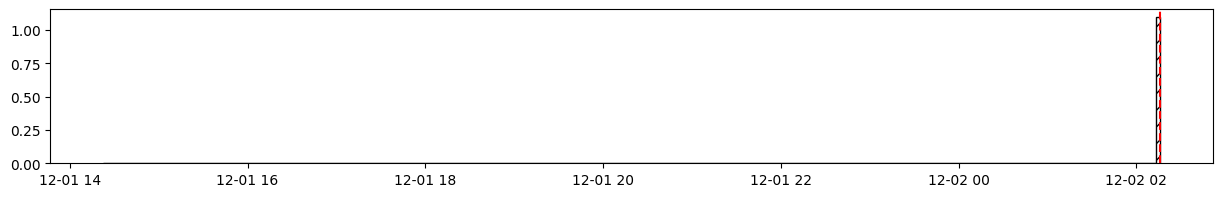

,PtID,DataDtTm,BolusDeliv,AutoModeStatus,DateTime
2797121,23,12/2/2018 2:13:43 AM,NaN,NaN,2018-12-02 02:13:43
2797120,23,12/2/2018 2:13:54 AM,2.40,NaN,2018-12-02 02:13:54
2797119,23,12/2/2018 2:14:42 AM,NaN,NaN,2018-12-02 02:14:42
2797117,23,12/2/2018 2:14:45 AM,NaN,NaN,2018-12-02 02:14:45
2797118,23,12/2/2018 2:14:45 AM,NaN,NaN,2018-12-02 02:14:45
2797115,23,12/2/2018 2:14:58 AM,NaN,NaN,2018-12-02 02:14:58
2797114,23,12/2/2018 2:14:58 AM,NaN,NaN,2018-12-02 02:14:58
2797116,23,12/2/2018 2:14:58 AM,NaN,NaN,2018-12-02 02:14:58
2797113,23,12/2/2018 2:14:59 AM,NaN,NaN,2018-12-02 02:14:59
2796843,23,12/2/2018 2:15:04 AM,1.40,NaN,2018-12-02 02:15:04


In [14]:
sample = cl_mdes.sample()
datetime = pd.to_datetime(sample.DateTime.values[0])
patient_id = str(sample.PtID.values[0])
display(sample)

#show surrounding extracted data
temp = basals[(basals.patient_id==patient_id) & (basals.datetime< (datetime+timedelta(hours=12))) & (basals.datetime > (datetime-timedelta(hours=12)))]
display(temp)

#plot the extracted basal rates
plt.figure(figsize=(15,2)) ; ax=plt.gca()
drawing.drawAbsoluteBasalRates(ax,temp.datetime.values, temp.basal_rate.values)
plt.axvline(datetime, color='r', linestyle='--')
plt.show()

#show context of raw data
context = pandas_helper.extract_surrounding_rows(flair.df_pump, sample.index[0],10,sort_by=['PtID','DateTime'])
display(context.dropna(axis=1, how='all'))

As we can see, the extracted data basal rate returns to zero when the closed loop mode is activated

## TDDs

In [15]:
tdd_reported = flair.get_reported_tdds().set_index(['patient_id','date']).drop(columns=['datetime']).rename(columns={'tdd':'tdd_reported'})
tdd_reported.head(3)

tdd_reported
patient_id date                    
1          2018-08-08        28.875
           2018-08-09        50.825
           2018-08-10        46.250

In [16]:
tdd_basal_extracted = flair.extract_basal_event_history().groupby('patient_id').apply(tdd.calculate_daily_basal_dose, include_groups=False);
tdd_bolus_extracted = flair.extract_bolus_event_history().groupby('patient_id').apply(tdd.calculate_daily_bolus_dose, include_groups=False);
tdds = pd.concat([tdd_basal_extracted, tdd_bolus_extracted, tdd_reported], axis=1).sort_index()
tdds['tdd_extracted']= tdds[['basal','bolus']].sum(axis=1)
tdds.head(3)

basal  bolus  tdd_reported  tdd_extracted
patient_id date                                                     
1          2018-08-08        NaN   16.5        28.875      16.500000
           2018-08-09  24.870528   26.0        50.825      50.870528
           2018-08-10  30.171111   16.1        46.250      46.271111

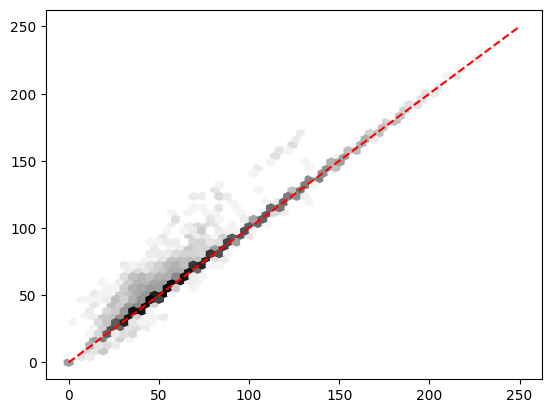

In [17]:
plt.hexbin(tdds.tdd_reported, tdds.tdd_extracted, gridsize=50, cmap='Greys', bins='log')
plt.plot([0,250],[0,250], '--r')

## Visualize Patient Data

Visualize raw and extracted data of patient 12

In [ ]:
flair.extract_basal_event_history()
flair.extract_bolus_event_history()
flair.extract_cgm_history()

In [ ]:
from src.find_periods import find_periods
import numpy as np
from date_helper import convert_duration_to_timedelta
%matplotlib widget

/var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_3965/1210054380.py:25: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  drawing.drawTempBasal(ax, tmpBasals.DateTime.dt.to_pydatetime(),


/var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_3965/1210054380.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


Text(0.5, 1.0, 'Basal and micro-boluses for patient 12')

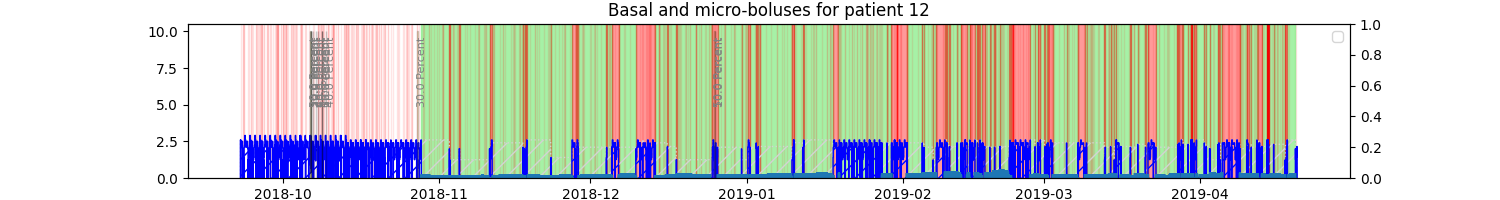

In [54]:
#get patient data
patient = 12
#raw
sub_df_pump = flair.df_pump.loc[flair.df_pump.PtID == patient].sort_values('DateTime')
#extracted 
basal_events_extracted = flair.extract_basal_event_history()
basal_events_extracted = basal_events_extracted[basal_events_extracted.patient_id==str(patient)]

#draw 
f = plt.figure(figsize=(15,2)); ax = f.gca(); twin_ax = ax.twinx()

#raw basals
basals_raw = sub_df_pump.dropna(subset=['BasalRt'])
drawing.drawAbsoluteBasalRates(ax, basals_raw.DateTime.values, basals_raw.BasalRt.values,edgecolor='lightgray',linestyle=':')

#extracted basals
drawing.drawAbsoluteBasalRates(ax, 
                               basal_events_extracted.datetime.values,
                               basal_events_extracted.basal_rate.values, edgecolor='blue', linestyle='-')


# temp basals
tmpBasals = sub_df_pump.dropna(subset=['TempBasalAmt'],axis=0)
if len(tmpBasals)>0:
    drawing.drawTempBasal(ax, tmpBasals.DateTime.dt.to_pydatetime(), 
                          tmpBasals.TempBasalAmt.values, 
                          tmpBasals.TempBasalDur.values,
                           tmpBasals.TempBasalType.values)

#suspends
suspends = sub_df_pump.dropna(subset=['Suspend'])
susupend_periods_on = find_periods(suspends, 'Suspend', 'DateTime',lambda x: x != 'NORMAL_PUMPING', lambda x: x == 'NORMAL_PUMPING')
for period in susupend_periods_on:
    ax.axvspan(period.time_start, period.time_end, color='red', zorder=0.2, alpha=0.1, 
               label='suspend' if period == susupend_periods_on[0] else None)

#

## Auto Mode Status
on_periods = find_periods(sub_df_pump, 'AutoModeStatus', 'DateTime', lambda x: x, lambda x: not x)
off_periods = find_periods(sub_df_pump, 'AutoModeStatus', 'DateTime', lambda x: not x, lambda x: x)
#background on (green)
for period in on_periods:
    ax.axvspan(period.time_start, period.time_end, color='lightgreen', alpha=0.8,zorder=0.1, label='CL on' if period == on_periods[0] else None)
#background off (red)
for period in off_periods:
    ax.axvspan(period.time_start, period.time_end, color='red', alpha=0.4,zorder=0.2, label='CL off' if period == off_periods[0] else None)
# #on events
# temp = sub_df_pump.loc[sub_df_pump.AutoModeStatus==True]
# if len(temp)>0:
#     ax.scatter(temp.DateTime, np.ones(len(temp))*3, marker='^', color='green', label='AutoModeStatus True')
# #off events
# temp = sub_df_pump.loc[sub_df_pump.AutoModeStatus==False]
# if len(temp)>0:
#     ax.scatter(temp.DateTime, np.ones(len(temp))*3, marker='v', color='red', label='AutoModeStatus False')

#micro boluses
micro_boluses = sub_df_pump[sub_df_pump.BolusSource.isin(['CL_MICRO_BOLUS', 'CLOSED_LOOP_MICRO_BOLUS'])]
if len(micro_boluses)>0:
    ax.stem(micro_boluses.DateTime.values, micro_boluses.BolusDeliv.values, linefmt='C0-', markerfmt='None', basefmt='None', label='micro',)

# #cgm
# if len(sub_df_cgm)>0:
#     twin_ax.scatter(sub_df_cgm.DateTime, sub_df_cgm.CGM, label='CGM', color='gray', marker='.',s=1)

plt.legend(loc='upper right')
plt.title(f"Basal and micro-boluses for patient {patient}")

#plt.xlim(sub_df_pump.DateTime.min(), sub_df_pump.DateTime.min()+timedelta(days=1))

